# Inpainting

## Problem Setting

Inpainting problems fill the missing parts of an image by using the semantic information and texture from the surrounding visible context. The goal is to reconstruct the missing pixels so that the completed image is close to the original.

One approach is to treat this problem as a supervised image-to-image regression task. 

For each clean RGB image $𝑥$, we create a corrupted input by applying a binary mask $M$ that hides a contiguous rectangular region.

Under a shared training and evaluation protocol, three baselines are compared: (1) non-learning PDE-based inpainting methods, (2) a simple encoder–decoder autoencoder without skip connections, and (3) an improved U-Net-like architecture designed to better preserve spatial detail.


## Formal Definition
Let $x \in \mathbb{R}^{H \times W \times C}$ be a clean image with height $H$, width $W$ and $C = 3$ color channels. 
We define a **binary mask**  $M \in \{0,1\}^{H \times W}$ that determines which parts of the image are visible. The values of the mask are denoted as 
$$
M_{i,j} =
\begin{cases}
1 & \text{if pixel } (i,j) \text{ is visible (known)} \\
0 & \text{if pixel } (i,j) \text{ is missing}
\end{cases}
$$

The corrupted **input image** $x_{\text{masked}}$ is generated by applying the mask to the original image:
$$x_{\text{masked}} = M \odot x,$$
where $\odot$ denotes element-wise multiplication (Hadamard product) and the mask is broadcast over channels. 
This results to pixel values equal zero in the missing regions (where $M=0$). 

The **learning task** is to train a function $f_\theta$ that reconstructs the original image $x$ from the masked input $x_{\text{masked}}$ and mask $M$:
$$\hat{x} = f_\theta(x_{\text{masked}}, M)$$
where $\hat{x}$ represents the reconstructed output image.

During training the distance-based loss $L$ between the prediction $\hat{x}$ and the ground truth image $x$ is minimzed:
$$
\theta^{*} \;=\; \arg\min_{\theta}\, L\!\big(f_{\theta}(x_{\text{masked}}, M),\, x\big)
$$
To assess the inpainting quality the loss $L$ is computed exclusively on the missing region using $(1−M)$, so the model is rewarded for reconstruction rather than copying known pixels.
$$
L_{\text{miss}} \;=\;
\frac{\sum \left| \hat{x} - x \right|\,(1 - M)}
{\sum (1 - M)}
$$

### Dataset and Dataset Split
For this task **Places365** (v2) has been used which consists of high-resolution photographs covering a wide variety of indoor and outdoor scenes (e.g., landscapes, buildings, rooms)

It has higher resolution than e.g. CIFAR10 and unlike basic datasets (e.g. MNIST) it contains complex natural textures. This makes the inpainting task not trivial, since it forces the model to actually learn meaningful structural representations and texture rather than simple geometric interpolation.

At the same time the scenes contain repetitive structure which allows the model to converge within reasonable computational limits. Furthermore, due to this reason, the models are only trained on a **small subset** of the official **validation split**. The validation split was chosen intentionally as it contains clean high-quality samples. 


flag: DEV or PRODUCTION
DEV: 
- Kaggle or local
- setze pfade accordingly
- große daten wie datensatz oder checkpoints checken if vorhanden, sonst laden (von wo?)
PRODUCTION: Colab or local
- setze pfade accordingly
- große daten wie datensatz oder checkpoints checken if vorhanden, sonst laden (von wo?)
- wandb disabeln

In [3]:
from enum import Enum
from pathlib import Path
import sys
import os

class Runtime(Enum):
    KAGGLE = "kaggle"
    COLAB  = "colab"
    LOCAL  = "local"

class Mode(Enum):
    DEV  = "dev"
    PROD = "prod"

MODE = Mode.DEV

def detect_runtime() -> Runtime:
    if Path("/kaggle/input").exists() and Path("/kaggle/working").exists():
        return Runtime.KAGGLE
    elif "google.colab" in sys.modules:
        return Runtime.COLAB
    else:
        return Runtime.LOCAL

RUNTIME = detect_runtime()
print("[setup] MODE:", MODE.value, "| RUNTIME:", RUNTIME.value)

[setup] MODE: dev | RUNTIME: local


In [4]:
HF_DATASET = "mmarschn/inpainting_validPlaces"  
HF_CHECKPOINTS   = "mmarschn/inpainting_checkpoints" 

In [5]:
import os
from pathlib import Path

_MARKERS = (".git", "pyproject.toml", "requirements.txt", "setup.cfg")

def find_repo_root(start: Path | None = None) -> Path:
    """
    Find the repository root by walking upwards looking for marker files.
    Priority:
      1) CODE_ROOT env var (explicit override)
      2) walk up from `start` (default: cwd)
    """
    env = os.getenv("CODE_ROOT")
    if env:
        p = Path(env).expanduser().resolve()
        if not p.exists():
            raise FileNotFoundError(f"CODE_ROOT is set but does not exist: {p}")
        return p

    cur = (start or Path.cwd()).resolve()
    for parent in (cur, *cur.parents):
        if any((parent / m).exists() for m in _MARKERS):
            return parent

    # last resort: cwd
    return cur

In [6]:
CODE_ROOT = find_repo_root()
print(CODE_ROOT)

/Users/MicheleMarschner/Documents/Uni/WiSe_2025_26/MLII/Inpainting-with-deep-learning


In [20]:
if RUNTIME == Runtime.COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    os.environ["CODE_ROOT"] = "/content/drive/MyDrive/inpainting"

# Setup

In [8]:

from pathlib import Path
import sys

os.environ["PYTHONHASHSEED"] = "51"

In [17]:
def setup_environment():

    if RUNTIME == Runtime.KAGGLE:
        # set paths
        CODE_ROOT = Path("/kaggle/input/inpainting")
        DATA_DIR = Path("/kaggle/input/places2-val-256/val_256")
        WORK_ROOT = Path("/kaggle/working/inpainting")
        WORK_ROOT.mkdir(parents=True, exist_ok=True)
        CHECKPOINTS_DIR = Path("/kaggle/working/inpainting_checkpoints")

        os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

        # set environment variables: load from kaggle secrets
        from kaggle_secrets import UserSecretsClient
        user_secrets = UserSecretsClient()
        os.environ["WANDB_API_KEY"] = user_secrets.get_secret("WANDB_API_KEY")


    if RUNTIME == Runtime.COLAB:
        ## mount drive
        ## 
        CODE_ROOT = Path("/kaggle/input/inpainting")
        DATA_DIR = Path("/kaggle/input/places2-val-256/val_256")
        WORK_ROOT = Path("/kaggle/working/inpainting")
        WORK_ROOT.mkdir(parents=True, exist_ok=True)
        CHECKPOINTS_DIR = Path("/kaggle/working/inpainting_checkpoints")

    else:
        # set paths
        ROOT = Path.cwd().parents[0]        # sets project url as root url
        # Dataset root (can be outside the repo)
        CODE_ROOT = ROOT
        DATA_ROOT = Path(os.getenv("DATA_DIR", ROOT / "data"))
        DATA_DIR = DATA_ROOT / "inpainting/places2/val_256"
        WORK_ROOT = ROOT
        CHECKPOINTS_DIR = ROOT / "checkpoints"
        CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)

        # set environment variables
        from dotenv import load_dotenv
        load_dotenv()


    sys.path.insert(0, str(CODE_ROOT / "src"))      # allow Python to import modules from the project's src/ directory

    return DATA_DIR, CHECKPOINTS_DIR, CODE_ROOT, WORK_ROOT

In [18]:
DATA_DIR, CHECKPOINTS_DIR, CODE_ROOT, WORK_ROOT = setup_environment()

print(
    f"[env] CODE_ROOT={CODE_ROOT}\n"
    f"[env] DATA_DIR={DATA_DIR}\n"
    f"[env] WORK_ROOT={WORK_ROOT}\n"
    f"[env] CHECKPOINTS_DIR={CHECKPOINTS_DIR}"
)

[env] CODE_ROOT=/Users/MicheleMarschner/Documents/Uni/WiSe_2025_26/MLII/Inpainting-with-deep-learning
[env] DATA_DIR=/Users/MicheleMarschner/Datasets/inpainting/places2/val_256
[env] WORK_ROOT=/Users/MicheleMarschner/Documents/Uni/WiSe_2025_26/MLII/Inpainting-with-deep-learning
[env] CHECKPOINTS_DIR=/Users/MicheleMarschner/Documents/Uni/WiSe_2025_26/MLII/Inpainting-with-deep-learning/checkpoints


In [19]:
# Install dependencies
%cd $CODE_ROOT
%pip install --no-cache-dir -r requirements.txt

/Users/MicheleMarschner/Documents/Uni/WiSe_2025_26/MLII/Inpainting-with-deep-learning
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 53.3 MB/s  0:00:00 eta 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 56.4 MB/s  0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.9/18.9 MB 55.1 MB/s  0:00:00 eta 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... error
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1

In [29]:
# Imports
import torch
import torchvision.transforms.v2 as transforms
from torch.utils.data import Dataset, Subset, DataLoader
import torch.nn as nn
import torch.nn.functional as F

from PIL import Image
from typing import Optional, Tuple
import math
import random
import time
import json

import matplotlib.pyplot as plt
from tqdm import tqdm

import wandb

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="pydantic")


#from config import (DEVICE, NUM_WORKERS, SEED, PROJECT_ROOT, CHECKPOINTS_DIR, PLACES_DATASET_DIR) 
from utils import set_seeds, init_wandb, get_train_stats, format_time, unnormalize, cleanup
from visualization import show_dataset_grid, show_img_grid, show_norm_img_grid, plot_val_losses


In [30]:
# Constants

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = 0     # easier to ensure reproducibility
SEED = 51

TEST_FRAC = 0.1
VAL_FRAC = 0.2

H_MASK = 70
W_MASK = 90

TEST_SAMPLE_IDX = 40
NUM_DIFFUSION_ITERS=400

NUM_SAMPLES = 2000
IMG_SIZE = 256
BATCH_SIZE = 32

EPOCHS = 10
LR = 1e-4
BASE = 64     # 32, later 64

We fix all random seeds for Python, NumPy, and PyTorch, disabled nondeterministic CuDNN behavior, and use a single-worker DataLoader to ensure reproducible training runs

In [31]:
# Set random seeds for reproducibility across Python, NumPy, and PyTorch.
set_seeds(SEED)

Seeds set to 51


In [32]:
# Authenticate with Weights & Biases (W&B) to enable experiment tracking/logging.
if RUNTIME != Runtime.LOCAL:
    wandb.login()

# Data Loading & Split

In this section, the `Places365` images are loaded using a simple dataset that reads RGB .jpg files and applies tensor/normalization transforms, using only the first `NUM_SAMPLES` images for compute reasons. 

A deterministic train/val/test split is created by shuffling indices with a fixed seed and wrapping them with Subset, to ensure that all models are trained and evaluated on the exact same images.

Finally, we build DataLoaders where only the training loader is shuffled (still reproducibly), while validation and test loaders remain fixed to guarantee consistent evaluation.

In [33]:
class ImageDataset(Dataset):
    """Loads .jpg images from a folder and returns one image tensor per index."""
    def __init__(
        self,
        root: str,
        start_idx: int = 0,
        end_idx: Optional[int] = None,
        transform: Optional[callable] = None,
    ):
        # Root directory that contains the image files
        self.root = Path(root)

        self.transform = transform

        # Collect all .jpg/.JPG files and sort for deterministic, reproducible indexing
        files = sorted(list(self.root.glob("*.jpg")) + list(self.root.glob("*.JPG")))

        # Error if folder is empty / path is wrong
        if len(files) == 0:
            raise FileNotFoundError(f"No .jpg images found in {self.root}")

        # Optionally work on only a subset of the folder
        self.files = files[start_idx:end_idx]

        # Fail early if the chosen slice contains no files
        if len(self.files) == 0:
            raise ValueError("Selected subset is empty (check start_idx/end_idx)")

    def __len__(self) -> int:
        return len(self.files)

    def __getitem__(self, idx: int) -> torch.Tensor:
        # Load image and force RGB
        img = Image.open(self.files[idx]).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img


In [26]:
img_base_transforms = transforms.Compose([
    transforms.ToImage(),                           # scales data into [0,1]
    transforms.ToDtype(torch.float32, scale=True)
])

# Load dataset
base_data = ImageDataset(DATA_DIR, start_idx=0, end_idx=NUM_SAMPLES, transform=img_base_transforms)

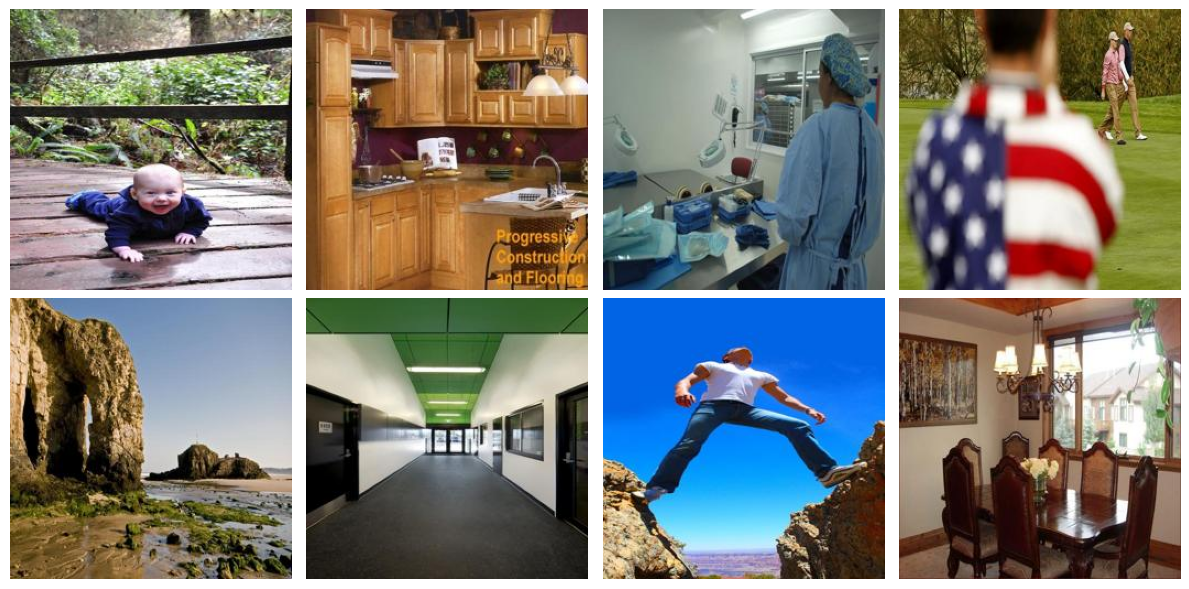

In [27]:
# Show some samples from the dataset
fig, ax = show_dataset_grid(base_data, 8, 4)
plt.show()

In [34]:
def train_test_val_split(
    dataset,
    val_frac: float = 0.1,
    test_frac: float = 0.1,
    seed: int = 51,
) -> Tuple[Subset, Subset, Subset]:
    """Reproducibly split a dataset into train/val/test Subsets using shuffled indices and given fractions."""
    
    n = len(dataset)

    # Use a dedicated RNG with a fixed seed so the split is reproducible
    g = torch.Generator().manual_seed(seed)

    # Create a random permutation of indices
    perm = torch.randperm(n, generator=g).tolist()

    # Convert fractions into absolute split sizes
    n_val = int(round(n * val_frac))
    n_test = int(round(n * test_frac))

    # Put all remaining samples into train (guarantees train+val+test == n)
    n_train = n - n_test - n_val

    # Slice the shuffled indices into three non-overlapping sets
    train_idx = perm[:n_train]
    val_idx   = perm[n_train:n_train + n_val]
    test_idx  = perm[n_train + n_val:]

    # Wrap the original dataset with Subset views (no data is copied)
    return Subset(dataset, train_idx), Subset(dataset, val_idx), Subset(dataset, test_idx)


In [35]:
# Split the base dataset into reproducible train/validation/test subsets
train_base_data, val_base_data, test_base_data = train_test_val_split(
    base_data,
    val_frac=VAL_FRAC,
    test_frac=TEST_FRAC,
    seed=SEED
)

# Data Preprocessing

In this section the images are being preprocessed to ensure numerical stability and properly define the inpainting task. 

The pipeline consists primarily of feature standardization to aid optimization and deterministic mask generation to simulate the missing regions.

## Normalization

The process utilizes Z-score normalization, defined by the equation:
$$ x' = \frac{x - \mu_{\text{train}}}{\sigma_{\text{train}}} $$

**Where:**
- $x$ is the original input value (e.g. a pixel intensity or feature value)
- $\mu_{\text{train}}$ is the **mean computed on the training set**
- $\sigma_{\text{train}}$ is the **standard deviation computed on the training set**
- $x'$ is the normalized (standardized) value

Standardization creates a centered data distribution with unit variance, which prevents numerical instabilities like vanishing gradients and ensures that features with larger raw magnitudes do not dominate the loss function.

Crucially, the statistics are derived exclusively from the training set to prevent data leakage. Applying these fixed parameters to the test set ensures a rigorous evaluation that simulates real-world inference on unknown data.

In [36]:
# Compute per-channel mean and std from the training subset for consistent normalization
MEAN, STD = get_train_stats(dir=CODE_ROOT, batch_size=BATCH_SIZE, dataset=train_base_data)

Load from file...


In [37]:
class TransformDataset(Dataset):
    """Wraps an existing dataset and applies a transform to each sample"""
    def __init__(self, base: Dataset, transform):
        self.base = base
        self.transform = transform

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x = self.base[idx]
        return self.transform(x)

# Mask generation and Application

To simulate the inpainting task, we synthetically corrupt valid images by occluding specific regions. 

We employ contiguous rectangular masks rather than random pixel dropout. Removing large, connected blocks forces the model to learn semantic spatial context and texture synthesis, whereas pixel dropout would merely require local denoising (interpolation).

### Deterministic Mask Assignment

We use a **deterministic masking strategy** where the occluded region is chosen randomly but remains **fixed per image**. By deriving the random seed from the image index, we ensure that a specific image always receives the same missing region across all training epochs. This prevents the network from effectively “seeing behind” the mask over time, encouraging it to learn reconstruction rather than memorize the hidden ground truth.

### Input Representation

The masking process generates a binary tensor:
$$
M \in \{0,1\}^{H \times W},
$$
where $( M_{ij} = 1)$ indicates known pixels and $( M_{ij} = 0)$ indicates the missing region. The masked input image is computed by element-wise multiplication:
$$
I_{\text{masked}} = I_{\text{original}} \odot M.
$$

In practice the mask is concatenated to the RGB input to form a 4-channel tensor of shape $(H×W×4)$. This explicitly tells the network which pixels are valid and which must be reconstructed, avoiding ambiguity in zero-valued regions.







In [38]:
class InpaintingDataset(Dataset):
    """
    Wrapper dataset: applies masks on-the-fly and returns (x_in, y, mask), where
      y     = original image tensor (C,H,W)
      mask  = binary mask tensor (1,H,W), 1=visible, 0=missing
      x_in  = either masked image (C,H,W) OR concat(masked image, mask) (C+1,H,W)

    Deterministic masks: seed derived from (global_seed + idx) OR from filename hash (more robust).
    """
    def __init__(
        self,
        base: Dataset,
        h_mask: int,
        w_mask: int,
        seed: int = 51,
        # fixed_mask_per_image: bool = True,        ## later extension with random masks for.each img
    ):
        self.base = base
        self.h_mask = h_mask
        self.w_mask = w_mask
        self.seed = seed
        #self.fixed = fixed_mask_per_image          ## later extension with random masks for.each img

    def __len__(self):
        return len(self.base)
    
    def _rng_for(self, idx: int) -> random.Random:
        ## later extension with random masks for.each img
        #if not self.fixed:
        #    return random.Random()  # nondeterministic
        return random.Random(self.seed + idx)
        
    def __getitem__(self, idx: int):
        img = self.base[idx]                             # (C,H,W) tensor
        
        C, H, W = img.shape
        # ensures that mask is not bigger than the image
        h = min(self.h_mask, H)
        w = min(self.w_mask, W)

        rng = self._rng_for(idx)

        # pick top-left so rectangle stays inside image
        top = rng.randint(0, H - h)
        left = rng.randint(0, W - w)

        # create mask: 1 everywhere, 0 inside rectangle
        mask = torch.ones((1, H, W), dtype=torch.float32)
        mask[:, top:top + h, left:left + w] = 0.0

        # apply mask (broadcast over channels); Masked image = original image × mask
        masked_img = img * mask

        # includes the mask as extra channel
        x_in = torch.cat([masked_img, mask], dim=0)  # (C+1,H,W)

        return x_in, img, mask

In [39]:
train_data = InpaintingDataset(train_base_data, H_MASK, W_MASK, SEED)
val_data   = InpaintingDataset(val_base_data, H_MASK, W_MASK, SEED)
test_data  = InpaintingDataset(test_base_data, H_MASK, W_MASK, SEED)

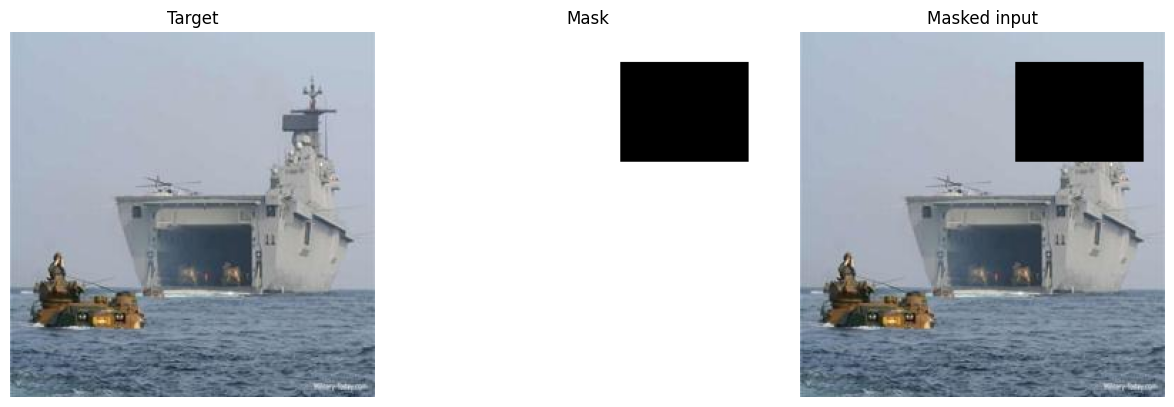

In [40]:
x_in, img, mask = test_data[TEST_SAMPLE_IDX]

show_img_grid(
    tensors=[img, mask, x_in],
    titles=["Target", "Mask", "Masked input"]
)
plt.show()

In [41]:
g = torch.Generator()
g.manual_seed(SEED)

## TODO: should I try to make the train loader deterministic?
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  generator=g, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Baseline

To evaluate the deep learning models, a baseline is established using classical inpainting methods based on partial differential equations (PDEs). These approaches rely purely on mathematical interpolation, without any learned semantic knowledge. 

In the literature, methods such as Navier-Stokes [Bertozzi et al., 2001] or Fast Marching [Telea, 2004] are standard non-learning baselines. Both methods fill missing regions by propagating information from the hole boundary inward. 

The three baseline variants used in this project belong to the same PDE-based family. The first is a Laplace/diffusion baseline (smoothest-fill). The second is a Fast-Marching-style propagation baseline (boundary-to-center filling). The third is a hybrid that combines both methods. 

This baseline provides a computationally cheap reference point to quantify how much improvement is gained by neural networks. It also acts as a control: if a learned model does not clearly outperform the PDE baseline, it likely learns mostly smoothing rather than meaningful scene reconstruction.

## Baseline 1: Standard Iterative Diffusion (Laplace Equation)

In this approach, every missing pixel is updated iteratively by taking the simple average of its four immediate neighbors (top, bottom, left, right), regardless of whether those neighbors are known or missing.

This is the classic implementation of smoothing. Since the missing region is initialized as black (zeros), these empty values initially drag down the local averages. This results in a very gradual, blurry fill that takes many iterations to propagate color from the edges to the center.

There is a direct trade-off with the number of iterations: running the process longer allows colors to reach the center of the hole, but it also results in a "flatter," more blurry image as the values converge to a perfectly smooth gradient. 

We selected 200 iterations as a balanced stopping point—sufficient to fill the hole without wasting computational resources on over-smoothing the result.

In [42]:
@torch.no_grad()
def diffusion_inpaint(
    masked: torch.Tensor,   # (B, C, H, W) masked image (missing area typically 0)
    mask: torch.Tensor,     # (B, 1, H, W) 1=known, 0=missing
    num_iters: int = 200,   # more iterations = smoother fill, but more blur
) -> torch.Tensor:
  """
  Simple diffusion / neighbor-averaging inpainting baseline.

  Updates only missing pixels each iteration:
    x_missing <- avg_4_neighbors(x)

  Returns:
    filled image (B, C, H, W)
  """
  B, C, H, W = masked.shape
  device = masked.device
  dtype = masked.dtype

  known = mask  # (B,1,H,W)
  missing = 1.0 - known

  # create a kernel with +1 for neighboring pixel
  # 4-neighbor averaging kernel applied for each channel
  kernel = torch.tensor(
      [[0.0, 1.0, 0.0],
        [1.0, 0.0, 1.0],
        [0.0, 1.0, 0.0]],
      device=device, dtype=dtype
  ).view(1, 1, 3, 3)

  # Apply the kernel on each channel; same neighbor-averaging operation applied independently to each RGB channel.
  kernel = kernel.repeat(C, 1, 1, 1)    # (C,1,3,3)

  # Make a copy of the input image to not overwrite permanently
  img_inpainted = masked.clone()

  # In each iteration apply the kernel via Conv2d on the whole image and fill current pixel with average value
  # of neighbours
  for _ in range(num_iters):
    neigh_sum = F.conv2d(img_inpainted, kernel, padding=1, groups=C)  # sum values of all neighbour 

    # Average over number of neighbours
    # Each pixel has up to 4 neighbors; near borders fewer -> normalize by neighbor count
    ones = torch.ones((B, 1, H, W), device=device, dtype=dtype)
    neigh_count = F.conv2d(ones, kernel[:1], padding=1)  # (B,1,H,W)
    neigh_avg = neigh_sum / (neigh_count + 1e-8)         # (B,C,H,W) via broadcast

    # Only update missing region; rest of the image stays unchanged
    img_inpainted = img_inpainted * known + neigh_avg * missing

  return img_inpainted[:3]


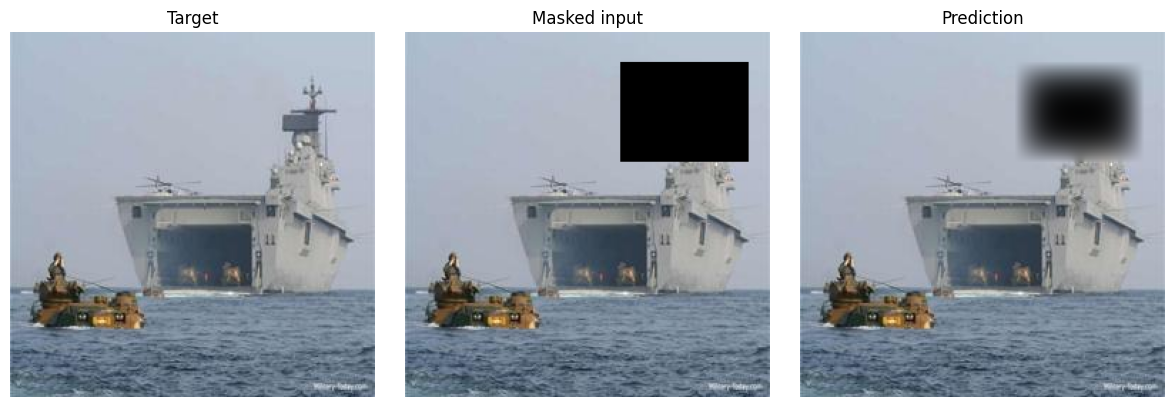

In [43]:
# Run the baseline on a single test sample and visualize
x_in, img, mask = test_data[TEST_SAMPLE_IDX]
masked_img = x_in[:3].unsqueeze(0) 
pred_diffusion = diffusion_inpaint(masked_img, mask, num_iters=NUM_DIFFUSION_ITERS)

show_img_grid(
    tensors=[img, x_in, pred_diffusion.squeeze(0)],
    titles=["Target", "Masked input", "Prediction"]
)
plt.show()

## Baseline 2: Known-Neighbors-Only ("Wavefront")

This method imposes a strict constraint on the averaging process. A missing pixel is updated only if it is adjacent to at least one "known" pixel (either from the original image or a previously filled region). The new value is calculated as the average of these valid neighbors exclusively, ignoring any neighbors that are still empty.

This creates a "wavefront" effect where the hole fills layer-by-layer from the boundary inward. It prevents the initial black values (zeros) from contaminating the result. This approach generally yields sharper results and converges faster than standard diffusion because it relies purely on valid data.

In [44]:
@torch.no_grad()
def inpaint_known_neighbors_only(
    masked: torch.Tensor,  # (B,C,H,W) missing pixels can be 0
    mask: torch.Tensor,    # (B,1,H,W) 1=known, 0=missing
    max_iters: int = 500,
    tol: float = 0.0,      # set >0 for early stopping (optional)
) -> torch.Tensor:
    """
    Fill missing pixels using ONLY neighbors that are currently known/filled.
    Vectorized "wavefront" inpainting: missing pixels fill from boundary inward.

    Returns:
      x_filled: (B,C,H,W)
    """
    
    B, C, H, W = masked.shape
    device, dtype = masked.device, masked.dtype

    # 4-neighbor kernel
    k = torch.tensor([[0., 1., 0.],
                      [1., 0., 1.],
                      [0., 1., 0.]], device=device, dtype=dtype).view(1,1,3,3)

    # per-channel grouped kernel
    kC = k.repeat(C, 1, 1, 1)  # (C,1,3,3)

    img_inpainted = masked.clone()
    K = mask.clone()  # (B,1,H,W) current knownness (starts with original known pixels)

    for _ in range(max_iters):
        img_inpainted_prev = img_inpainted

        # Sum ONLY from currently known pixels:
        # (x*K) broadcasts K across channels => (B,C,H,W)
        neigh_sum = F.conv2d(img_inpainted * K, kC, padding=1, groups=C)      # (B,C,H,W)
        neigh_cnt = F.conv2d(K, k, padding=1)                     # (B,1,H,W), counts known neighbors

        # Pixels we are allowed to fill this iteration:
        fillable = (K == 0) & (neigh_cnt > 0)                     # (B,1,H,W)

        # Compute average of known neighbors (avoid division by 0 via masking)
        neigh_avg = neigh_sum / (neigh_cnt + 1e-8)                # (B,C,H,W) via broadcast

        # Update ONLY fillable pixels (broadcast fillable to channels)
        fillableC = fillable.expand(-1, C, -1, -1)                # (B,C,H,W)
        img_inpainted = torch.where(fillableC, neigh_avg, img_inpainted)

        # Mark newly filled pixels as known for next iteration
        K = torch.where(fillable, torch.ones_like(K), K)

        # stop if everything filled
        if (K == 0).sum().item() == 0:
            break

        # optional early stop based on small changes
        if tol > 0.0:
            diff = (img_inpainted - img_inpainted_prev).abs()
            # consider only pixels that were updated this iter
            change = diff * fillableC
            if change.max().item() < tol:
                break

    return img_inpainted[:3]


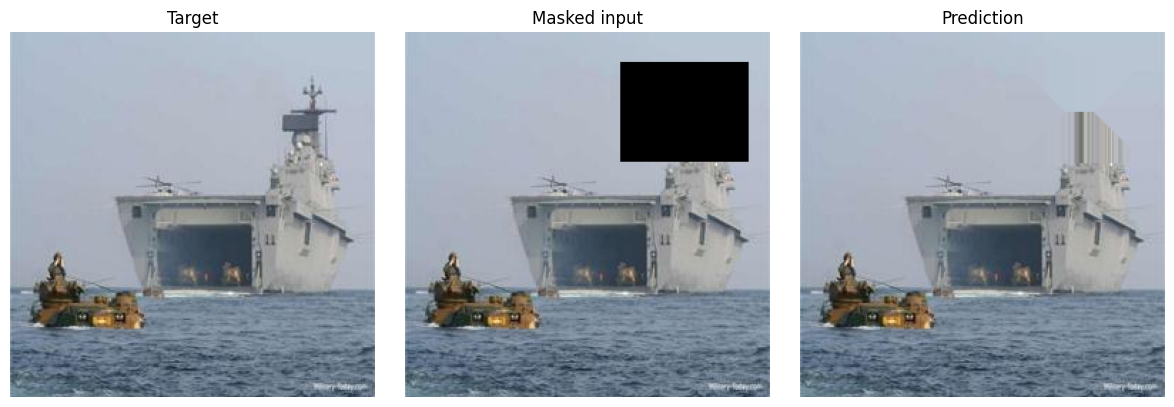

In [45]:
# Run the baseline on a single test sample and visualize
x_in, img, mask = test_data[TEST_SAMPLE_IDX]
masked_img = x_in[:3].unsqueeze(0)       # remove channel with mask

pred_only_neigh = inpaint_known_neighbors_only(masked_img, mask.unsqueeze(0), max_iters=NUM_DIFFUSION_ITERS)

show_img_grid(
    tensors=[img, x_in[:3], pred_only_neigh.squeeze(0)],
    titles=["Target", "Masked input", "Prediction"]
)
plt.show()

## Baseline 3: Weighted Diffusion

This is a hybrid approach of Baseline 1 and 2. It calculates the average of all four neighbors but assigns a higher importance (weight) to known pixels and a lower weight to missing ones.

Standard diffusion (Baseline 1) can be too slow and blurry, while "Known-Only" (Baseline 2) can sometimes produce hard, jagged artifacts where different "waves" meet. 

Weighting the known pixels higher prioritizes valid information while still allowing a small amount of smoothing from the undefined region, offering a compromise between the two extremes.


In [46]:
@torch.no_grad()
def diffusion_inpaint_weighted_knownness(
    masked: torch.Tensor,  # (B,C,H,W)
    mask: torch.Tensor,    # (B,1,H,W) 1=known, 0=missing
    num_iters: int = 400,
    alpha: float = 1.0,    # weight for missing neighbors (0 -> known-only; 1 -> standard diffusion)
) -> torch.Tensor:
    """
    Weighted diffusion inpainting:
    neighbors are averaged with weights depending on knownness:
    w = 1 for known pixels, w = alpha for missing pixels.

    alpha=1.0 -> standard diffusion
    alpha=0.0 -> known-neighbors-only averaging (but without wavefront logic)
    """
    assert masked.dim() == 4
    assert mask.dim() == 4 and mask.size(1) == 1
    B, C, H, W = masked.shape
    device, dtype = masked.device, masked.dtype

    k = torch.tensor([[0., 1., 0.],
                      [1., 0., 1.],
                      [0., 1., 0.]], device=device, dtype=dtype).view(1,1,3,3)
    kC = k.repeat(C, 1, 1, 1)

    known = mask
    missing = 1.0 - known

    # weights per pixel (known=1, missing=alpha)
    Wpix = known + alpha * missing   # (B,1,H,W)

    img_inpainted = masked.clone()

    for _ in range(num_iters):
        # weighted neighbor sum
        neigh_sum = F.conv2d(img_inpainted * Wpix, kC, padding=1, groups=C)   # (B,C,H,W)
        # weighted neighbor count
        neigh_wsum = F.conv2d(Wpix, k, padding=1)                # (B,1,H,W)

        neigh_avg = neigh_sum / (neigh_wsum + 1e-8)

        # keep known pixels fixed, update missing pixels
        img_inpainted = img_inpainted * known + neigh_avg * missing

    return img_inpainted


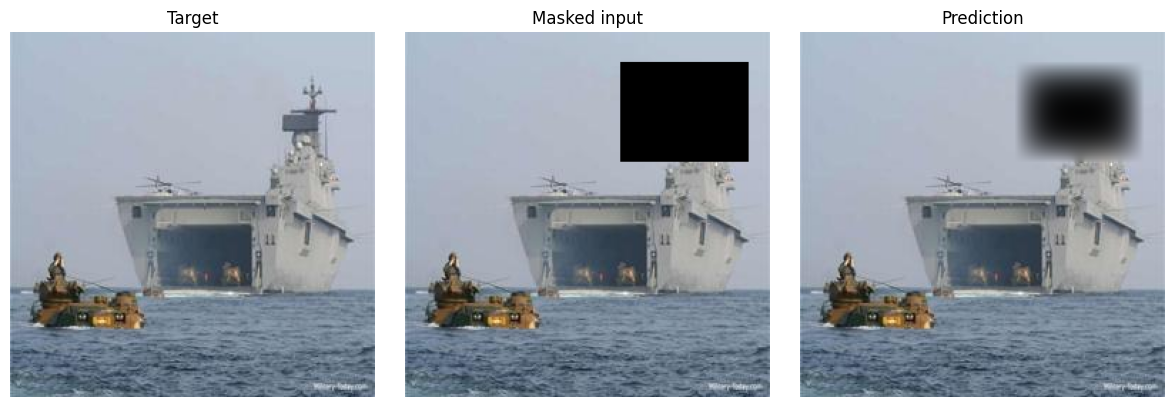

In [47]:
# Run the baseline on a single test sample and visualize
x_in, img, mask = test_data[TEST_SAMPLE_IDX]
masked_img = x_in[:3].unsqueeze(0)
pred_weigthed = diffusion_inpaint_weighted_knownness(masked_img, mask.unsqueeze(0), num_iters=NUM_DIFFUSION_ITERS)

show_img_grid(
    tensors=[img, x_in, pred_weigthed.squeeze(0)],
    titles=["Target", "Masked input", "Prediction"]
)
plt.show()

## Evaluation

To measure how well the model fills in missing parts, we evaluate only the masked (missing) region.

Full-image metrics are misleading here because most pixels are already known and stay unchanged. Inclusion of these known pixels would dilute the error signal, making poor reconstructions appear artificially high-quality. 

Therefore, we compute all metrics evaluating only the missing-region mask $(1 − 𝑀)$, so errors on known pixels are set to zero.

### Metrics: MAE and PSNR
We use two metrics that complement each other:

**1. Masked Mean Absolute Error (MAE):** This is the average absolute difference between the prediction and the ground truth only in the missing region. Compared to MSE, MAE is less dominated by a few large errors and often matches visual sharpness better.

For an RGB image, the masked mean absolute error (MAE) is defined as:
$$
\mathrm{MAE}_{\text{miss}} =
\frac{\sum_{i,j,c} \left| \hat{y}_{i,j,c} - y_{i,j,c} \right| \cdot (1 - M_{i,j})}
     {\sum_{i,j} (1 - M_{i,j})}
$$

where $\hat{y}$ is the reconstructed image and $y$ is the ground truth and $(1 - M)$ is the missing-pixel indicator. 

**2. Peak Signal-to-Noise Ratio (PSNR):** PSNR is a common reconstruction metric reported in logarithmic decibel (dB). It is computed from the masked MSE but shown on a log scale. It compares the maximum possible pixel value (“signal”) to the reconstruction error (“noise”). Higher PSNR values indicate better quality.

The peak signal-to-noise ratio (PSNR) on the missing region is given by:
$$
\mathrm{PSNR}_{\text{miss}} =
10 \log_{10}\left(
\frac{\mathrm{MAX}^2}{\mathrm{MSE}_{\text{miss}} + \varepsilon}
\right)
=
10 \log_{10}\left(
\frac{1}{\mathrm{MSE}_{\text{miss}} + \varepsilon}
\right)
$$
where $\varepsilon$ is a small constant added for numerical stability. For images scaled to $[0,1]$, the maximum possible pixel value is $\mathrm{MAX} = 1$.
The masked mean squared error (MSE) is defined analogously to the masked MAE.


### Global Aggregation Strategy
In `evaluate_miss`, we compute a global pixel-weighted average: we sum the total error over all missing pixels and divide by the total number of missing pixels (and channels). We do not average per-image scores. This ensures that every missing pixel contributes equally to the final score, preventing images with smaller masks distorting the final result.


In [48]:
def loss_miss_baseline(predictor_fn, batch, device, eps) -> torch.Tensor:
    """
    Computes reconstruction error (MAE and MSE) strictly on the missing regions.

    Used for evaluating baseline methods where predictions are generated on-the-fly.
    Returns both the batch-averaged loss and the raw sums to allow for accurate 
    global aggregation across the entire dataset.
    """
    x_in, y, mask = batch
    x_in, y, mask = x_in.to(device), y.to(device), mask.to(device)

    y_hat = predictor_fn(x_in, mask)

    # unnormalize: ensure valid pixel range [0, 1] for fair metric calculation.
    y_vis = y.clamp(0,1)
    yhat_vis = y_hat.clamp(0,1)

    missing = 1.0 - mask                                # Invert mask: 1 for missing pixels, 0 for known pixels
    abs_err = (yhat_vis - y_vis).abs() * missing        # absolute error only over missing regions
    abs_num = abs_err.sum() 

    sq_err = ((yhat_vis - y_vis) ** 2) * missing        # square error over missing regions  (needed for PSNR)     
    sq_num = sq_err.sum()                        
    
    denom = missing.sum() * y_vis.shape[1]          # calculate mean absolute error over all missing pixels 
                                                    # aggregated across the entire batch and all channels.

    loss = abs_num / (denom + eps)  # MAE_miss as training loss

    return loss, abs_num.detach(), sq_num.detach(), denom.detach()


In [49]:
@torch.no_grad()
def evaluate_miss(loader, predictor_fn, device, eps=1e-8, max_val=1.0):
    """
    Evaluates the model on the full dataset by computing the global MAE and PSNR 
    exclusively for the missing (masked) regions.

    This function aggregates errors across all batches before averaging. This ensures 
    a 'pixel-weighted' average (Option A), where every missing pixel in the dataset 
    contributes equally to the final score, regardless of which image it belongs to.
    """
    total_abs_num = 0.0
    total_sq_num = 0.0
    total_denom = 0.0

    for batch in loader:
        # Retrieve sums of errors (absolute & squared) and the count of missing pixels for this batch
        _, abs_num, sq_num, denom = loss_miss_baseline(predictor_fn, batch, device, eps)
        
        # Accumulate totals across the entire dataset to compute a global average.
        # This prevents small batches or images with small masks from skewing the result.
        total_abs_num += abs_num.item()
        total_sq_num += sq_num.item()
        total_denom += denom.item()               # Total count of missing pixels × channels

    # Calculate final metrics based on the total accumulated errors and pixel counts
    mae = total_abs_num / (total_denom + eps)
    mse = total_sq_num / (total_denom + eps)
    
    # PSNR (Peak Signal-to-Noise Ratio): Standard reconstruction metric (logarithmic).
    # Higher is better. It measures the ratio between the maximum possible signal (1.0) and the error noise (MSE).
    psnr = 10.0 * torch.log10(torch.tensor((max_val ** 2) / (mse + eps))).item()
    
    return mae, psnr

In [50]:
# Compute the reference metrics (MAE/PSNR) for the baseline
def diffusion_predictor(x_in, mask):
    masked_rgb = x_in[:, :3]  # (B,3,H,W)
    return diffusion_inpaint_weighted_knownness(masked_rgb, mask, num_iters=NUM_DIFFUSION_ITERS)


test_mae, test_psnr = evaluate_miss(test_loader, diffusion_predictor, device=DEVICE)
print("val MAE_miss (diffusion):", test_mae)
print("val PSNR_miss (diffusion):", test_psnr)

val MAE_miss (diffusion): 0.240495574983465
val PSNR_miss (diffusion): 9.773650765419006


### TODO: Iterpretation section
**Interpretation:**
MAE_miss ≈ 0.24 means: on average, your filled pixels are off by ~0.24 intensity per channel 
MAE_miss ≈ 0.24 :On average, each missing pixel channel is off by ~0.24 intensity.

“The diffusion baseline (iterative neighbor averaging / Laplacian inpainting) performs poorly on Places2, achieving MAE_miss = 0.57 and PSNR_miss = 2.69 dB. This is expected because diffusion enforces only smoothness and cannot reconstruct textures or semantic structure in complex scenes.”

“After computing metrics in pixel space ([0,1], inverse-normalized), the diffusion baseline achieves MAE_miss = 0.159 and PSNR_miss = 13.77 dB on the validation set, reflecting the limitations of smoothness-based inpainting on complex scenes.”

!!TODO Überprüfe Aussage: “Models are trained on normalized inputs, but MAE/PSNR are computed on de-normalized images in [0,1] to obtain interpretable reconstruction quality metrics.”


# Models

In [51]:
normalize_transforms = transforms.Compose([
    transforms.Normalize(MEAN, STD)     # Normalize for stability
])

In [52]:
def train_loss_miss(model, batch, device):
    """
    Computes the Masked Mean Absolute Error (MAE) loss for training.

    This function evaluates the model purely on its ability to hallucinate 
    the missing pixels. The loss is calculated in the normalized feature space 
    (not pixel space) to ensure stable gradient descent.
    """
    eps = 1e-8                  # numerical stability for division
    x_in, y, mask = batch       # x_in: (B,4,H,W), y: (B,3,H,W), mask: (B,1,H,W)
    x_in, y, mask = x_in.to(device), y.to(device), mask.to(device)

    y_hat = model(x_in)         # predict reconstructed RGB in the same (normalized) space as y

    missing = 1.0 - mask

    # ---- TRAIN LOSS (MAE, normalized space) ----
    abs_err = (y_hat - y).abs() * missing       # absolute reconstruction error, but only counted on missing pixels

    # mean over missing pixels and channels
    denom = missing.sum() * y.shape[1]      # calculates mean absolute error over all missing pixels, 
                                            # aggregated across the entire batch and all channels.
    loss = abs_err.sum() / (denom + eps)

    return loss         


In [53]:
@torch.no_grad()
def eval_sums_miss(model, batch, device, mean, std):
    """
    Computes raw error sums in pixel space [0,1] for global evaluation.

    Unlike training loss (which uses normalized features for stability), 
    validation metrics must be computed on the actual image intensities to 
    be interpretable (e.g., PSNR). Returns raw sums to enable mathematically 
    correct aggregation across the entire dataset.
    """
    x_in, y, mask = x_in.to(device), y.to(device), mask.to(device)

    y_hat = model(x_in)

    missing = 1.0 - mask

    # ---- VAL/TEST (pixel space for reporting metrics) ----
    y_pix = unnormalize(y, mean, std).clamp(0, 1)           # function: (B,3,H,W) -> (B,3,H,W) in [0,1]
    yhat_pix = unnormalize(y_hat, mean, std).clamp(0, 1)

    abs_err_pix = (yhat_pix - y_pix).abs() * missing        # sum of absolute errors, only on missing pixels
    abs_num = abs_err_pix.sum() 

    sq_err_pix = ((yhat_pix - y_pix) ** 2) * missing        # sum of squared errors, only on missing pixels  (needed for PSNR)     
    sq_num = sq_err_pix.sum()
    denom   = missing.sum() * y.shape[1]                    # Count total missing values (pixels × channels) for normalization later

    return abs_num.item(), sq_num.item(), denom.item()

## A) Autoencoder

In this section we start with a convolutional encoder–decoder autoencoder, introduced in the lecture, as a simple neural baseline for inpainting.

This architecture follows a classic Encoder-Bottleneck-Decoder structure. 
The Encoder progressively downsamples the input (MaxPool), compressing spatial information into a compact abstract representation (the bottleneck). This forces the model to learn high-level semantic features, such as shapes and textures—rather than merely memorizing pixel values.  

The Decoder then attempts to reconstruct the original image from this compressed state by upsampling step by step back to full resolution. The output is again a 3-channel RGB image.

The bottleneck forces the model to use spatial context (not just local interpolation), while the fully convolutional design preserves translation-equivariance and works naturally on images. 

In [54]:
class DoubleConvBlock(nn.Module):
    """Two 3×3 conv layers with BatchNorm+ReLU for local feature extraction and refinement."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            # bias=False is used because BatchNorm already includes a learnable bias term,
            # making a standard convolutional bias redundant.
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            #nn.GroupNorm(num_groups=num_groups, num_channels=out_ch),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            #nn.GroupNorm(num_groups=num_groups, num_channels=out_ch),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
        )
    def forward(self, x):
        return self.net(x)


class Down(nn.Module):
    """
    Encoder step: extract features (DoubleConv), then downsample by 2 to compresses spatial dimensions.
    Structure: DoubleConv -> MaxPool which reduces the image size by half (H/2, W/2)
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = DoubleConvBlock(in_ch, out_ch)  # learn richer features at this resolution
        self.pool = nn.MaxPool2d(2)                 # H,W -> H/2,W/2 

    def forward(self, x):
        x = self.conv(x)
        return self.pool(x)


class Up(nn.Module):
    """Decoder step: Restores spatial resolution (Upsample by 2) to reconstruct the image.
    Structure: Upsample -> Reduce Channels (1x1 Conv) -> DoubleConv
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="nearest")       # H,W -> 2H,2W
        self.reduce = nn.Conv2d(in_ch, out_ch, kernel_size=1)       # Reduce channel depth to match the next layer [B, in_ch, H, W] → [B, out_ch, H, W]
        self.conv = DoubleConvBlock(out_ch, out_ch)                 # refine details after upsampling
    
    def forward(self, x):
        x = self.up(x)
        x = self.reduce(x)
        return self.conv(x)


class InpaintAutoEncoder(nn.Module):               
    """
    Encoder–decoder baseline for inpainting (no skip connections). 
    Input: 4ch (RGB+mask), output: 3ch RGB.
    
    1. Encoder: Compress input into a low-res, high-level abstract representation (Bottleneck).
    2. Bottleneck: The network is forced to discard noise and rely on global context.
    3. Decoder: Reconstructs the full-resolution image from the latent features.
    """
    def __init__(self, in_ch=4, out_ch=3, base=64):
        super().__init__()
        # ---- Encoder: progressively downsample to build global context ---- 
        # 256 -> 128 -> 64 -> 32 -> 16
        self.e1 = Down(in_ch, base)         # 256 -> 128
        self.e2 = Down(base, base*2)    # 128 -> 64
        self.e3 = Down(base*2, base*4)  # 64 -> 32
        self.e4 = Down(base*4, base*8)  # 32 -> 16

        # bottleneck: highest-level representation (largest receptive field)
        # (16x16 resolution)
        self.bottleneck = DoubleConvBlock(base*8, base*16)   # 16 -> 16

        # ---- Decoder: upsample back to full resolution and refine ----
        # 16 -> 32 -> 64 -> 128 -> 256
        self.d4 = Up(base*16, base*8)   # 16 -> 32
        self.d3 = Up(base*8, base*4)    # 32 -> 64
        self.d2 = Up(base*4, base*2)    # 64 -> 128
        self.d1 = Up(base*2, base)      # 128 -> 256   

        # Output Head: Projects features back to RGB space (64 -> 3 channels)
        self.head = nn.Conv2d(base, out_ch, kernel_size=1)

    def forward(self, x_in):
        # Downsample
        x = self.e1(x_in)           # [B,4,H,W]
        x = self.e2(x)
        x = self.e3(x)
        x = self.e4(x)

        # Contextual processing
        x = self.bottleneck(x)

        # Upsample
        x = self.d4(x)
        x = self.d3(x)
        x = self.d2(x)
        x = self.d1(x)

        score = self.head(x)         # [B,3,H,W] (logits)
        return score

# Evaluation Protocol

# Training

This section defines a reproducible training and experiment workflow used for all CNN models. 

`train_model` runs the epoch loop: it trains on the masked MAE loss over the missing region, then evaluates after each epoch using dataset-aggregated MAE and PSNR computed only on the hole, and saves the checkpoint with the best validation MAE. 

`run_experiment` wraps the training by setting all configs and hyperparameters, instantiating the model architecture, and enabling logging for fair comparison across runs. 

`get_model` loads the saved checkpoint and outputs of a model if available, otherwise it triggers the training pipeline and returns the optimized model in evaluation mode for final testing.

In [55]:
def train_model(
    model, optimizer,
    train_dataloader, val_dataloader,
    epochs, model_save_path,
    mean, std,
    log_to_wandb=False,
    device=None,
):
    """
    Train an inpainting model and validate using MAE/PSNR on the missing region (dataset-aggregated).
    """
    train_losses, val_maes, val_psnrs, epoch_times = [], [], [], []
    best_val_mae = float("inf")

    for epoch in range(epochs):
        start_time = time.time()
        print(f"[Inpainting] Epoch {epoch+1}/{epochs}")

        # ----- TRAIN -----
        model.train()
        train_loss_epoch = 0.0

        for step, batch in enumerate(tqdm(train_dataloader)):
            optimizer.zero_grad(set_to_none=True)               # set_to_none=True is a slight memory optimization over writing zeros
            loss = train_loss_miss(model, batch, device)
            loss.backward()
            optimizer.step()
            train_loss_epoch += loss.item()

        # Average the batch losses for reporting
        train_loss_epoch /= (step + 1)
        train_losses.append(train_loss_epoch)
        print(f"train loss (batch avg mae): {train_loss_epoch:.4f}")

        # ----- VALID (dataset-aggregated metrics (global)) -----
        eps = 1e-8
        max_val = 1.0

        model.eval()
        total_abs, total_sq, total_denom = 0.0, 0.0, 0.0

        with torch.no_grad():
            for step, batch in enumerate(tqdm(val_dataloader, leave=False)):
                # Return raw error sums (numerator) and pixel counts (denominator).
                # Aggregate over all batches and average over whole dataset (not per-batch averages)
                abs_num, sq_num, denom = eval_sums_miss(model, batch, device, mean, std)
                total_abs += abs_num
                total_sq += sq_num
                total_denom += denom              # pixels × channels

            # Compute final metrics over the entire validation dataset to prevent
            #  small batches or images with small masks from skewing results
            val_mae = total_abs / (total_denom + eps)
            val_mse = total_sq / (total_denom + eps)
            val_psnr = 10.0 * math.log10((max_val ** 2) / (val_mse + eps))    # max_val: MAX pixel value (1.0 if images in [0,1])
    
        val_maes.append(val_mae)
        val_psnrs.append(val_psnr)

        print(f"val MAE_miss (pixel-weighted):  {val_mae:.4f}")
        print(f"val PSNR_miss:                 {val_psnr:.2f} dB")

        # Save model if metric improves (Best MAE)
        if val_mae < best_val_mae:
            best_val_mae = val_mae
            torch.save(model.state_dict(), model_save_path)
            print(f"  → New best saved (val MAE_miss {best_val_mae:.4f})")

       # Logging
        epoch_time = time.time() - start_time
        epoch_times.append(epoch_time)                              # raw seconds
        epoch_time_formatted = format_time(epoch_time)              # human-readable string for logging

        if log_to_wandb:
            wandb.log({
                "model": model.__class__.__name__,
                "epoch": epoch + 1,
                "train_loss": train_loss_epoch,
                "val_mae": val_mae,
                "val_psnr": val_psnr,
                "epoch_time": epoch_time_formatted,
                "lr": optimizer.param_groups[0]["lr"]
            })


    return {
        "train_loss": train_losses,
        "val_mae": val_maes,
        "val_psnr": val_psnrs,
        "epoch_times": epoch_times,
        "best_val_mae": float(best_val_mae),
        "num_params": sum(p.numel() for p in model.parameters() if p.requires_grad),
    }

In [56]:
def run_experiment(ModelCls, hyper_params, name, num_samples, 
                   train_loader, val_loader):
    """
    Set seeds, build model+optimizer from hyperparameters, run training, and return results 
    plus artifacts.
    """
    
    set_seeds(SEED)

    # Dynamic hyperparameter configuration:
    base = hyper_params["base"]
    lr = hyper_params["lr"]
    epochs = hyper_params["epochs"]

    # Dynamic model instantiation
    model = ModelCls(base=base).to(DEVICE)
    model_save_path = CHECKPOINTS_DIR / f"inpaint_{name}.pt"

    # Number of trainable parameters (for the comparison table)
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    init_wandb(
        model=model,
        opt_name = opt.__class__.__name__,
        name=name,
        num_params=num_params,
        sample_number=num_samples
    )

    results = train_model(
      model=model,
      optimizer=opt,
      train_dataloader=train_loader,
      val_dataloader=val_loader,
      epochs=epochs,
      model_save_path=model_save_path,
      mean=MEAN, std=STD,
      log_to_wandb=True,
      device=DEVICE
    )

    return results, model, opt

In [57]:
def load_model(model, model_path, device=DEVICE):
    """Load checkpoint weights, freeze parameters, and switch to eval mode."""
    # Load serialized weights;
    state_dict = torch.load(model_path, weights_only=True, map_location=device)     # map_location ensures compatibility if moving between CPU/GPU
    model.load_state_dict(state_dict, strict=True)      # Enforce exact structural match between the architecture and the saved weights

    # Freeze all parameters
    for p in model.parameters():
        p.requires_grad = False

    model.eval()

    return model

In [58]:
def get_model(ModelCls, hyper_params, dir=CODE_ROOT, name="autoencoder", train_loader=train_loader, val_loader=val_loader):
    """
    Load existing checkpoint+results if available; otherwise train, save, and return the 
    best frozen model.
    """
    
    model_path = dir / f"{CHECKPOINTS_DIR}/inpaint_{name}.pt"
    results_path = dir / f"outputs/results_{name}.json"

    # Check for existing artifacts (Lazy Loading)
    if model_path.exists() and results_path.exists():

        with open(results_path, "r") as f:
            results = json.load(f)

    else:
        # Trigger full training pipeline
        results, model, opt = run_experiment(ModelCls, hyper_params, num_samples=NUM_SAMPLES, name=name, 
                                             train_loader=train_loader, val_loader=val_loader)
        cleanup(model, opt)     # Free up GPU memory immediately after training which prevents OOM errors
        wandb.finish()

        # Persist computed metrics to disk
        out_dir = WORK_ROOT / "outputs"
        out_dir.mkdir(exist_ok=True)

        with open(out_dir / "results_autoencoder.json", "w") as f:
            json.dump(results, f, indent=2)

    # Re-instantiate a clean model architecture and load the best weights (Frozen state)
    print("Load model...")
    base = hyper_params["base"]
    model = ModelCls(base=base).to(DEVICE)
    model = load_model(model, model_path)

    return results, model

In [59]:
# Bundle hyperparameters in one dict so experiments are easy to reproduce and compare
hyper_params = {
    "lr": LR,
    "base": BASE,
    "epochs": EPOCHS
}

# Run experiment
results_autoencoder, best_autoencoder = get_model(ModelCls=InpaintAutoEncoder, hyper_params=hyper_params,
                               dir=CODE_ROOT, name="autoencoder",
                               train_loader=train_loader, val_loader=val_loader)


Load model...


In [60]:
@torch.no_grad()
def predict_one(model, x_in, target_norm, mask, device):
    """Predict one inpainted image and paste the prediction only into the missing region."""
    x_in_b = x_in.unsqueeze(0).to(device)   # (1,4,H,W)
    y_hat_norm = model(x_in_b).squeeze(0).cpu()  # (3,H,W)
    final_norm = (target_norm * mask) + (y_hat_norm * (1 - mask))

    return final_norm

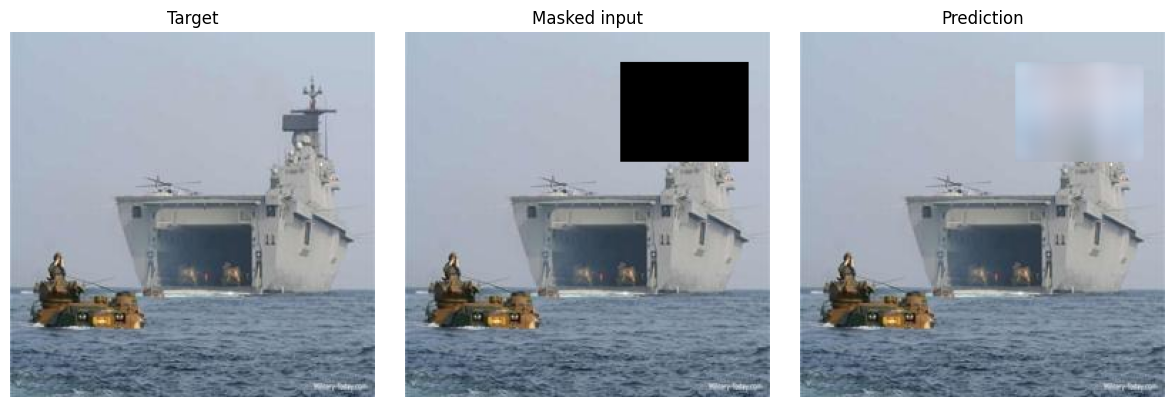

In [61]:
# Qualitative sanity check: Visually inspect the model output on a held-out test sample 
x_in, img, mask = test_data[TEST_SAMPLE_IDX]
pred_autoencoder = predict_one(best_autoencoder, x_in, img, mask, device=DEVICE)

fig, ax = show_img_grid(
    tensors=[img, x_in, pred_autoencoder.squeeze(0)],
    titles=["Target", "Masked input", "Prediction"],
)
plt.show()

In [62]:
# Free up GPU memory immediately after training to avoid OOM error
cleanup(best_autoencoder)

## Evaluation

### Observation

# TODO

### Limitation
All information must pass through the low-resolution bottleneck $(16×16)$. While this captures global context, it discards many fine details such as edges and textures. The decoder then has to recreate these details from the compressed representation alone, which often leads to blurry reconstructions.

## B) U-Net with Skip Connections (Concat)

In this section we use a U-Net-style architecture, introduced in the lecture, as a stronger CNN baseline for inpainting. It adresses the bottleneck issue by adding Skip Connections between corresponding layers of the Encoder and Decoder.

The encoder still builds global context by downsampling, while the decoder upsamples back to full resolution. The skip connections pass high-resolution feature maps directly to the decoder, which helps preserve fine spatial details such as edges and textures that are often lost in a bottleneck-only model.

This makes U-Net particularly well-suited for inpainting: the bottleneck captures the overall scene layout, while the skip connections carry detailed information (like edges and textures) directly to the decoder. This helps the model fill the hole more sharply and keeps the boundary between known and reconstructed pixels more stable.

In [63]:
class DownWithSkip(nn.Module):
    """ 
    Encoder block that preserves spatial features before downsampling. 
    Returns the high-res feature map, sent across to decoder and the downsampled feature map.
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = DoubleConvBlock(in_ch, out_ch)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        skip = self.conv(x)
        x = self.pool(skip)
        return skip, x


class UpWithSkip(nn.Module):
    """
    Decoder block that fuses global context with local details.
    Upsample -> (optional pad) -> concat with skip -> DoubleConv
    """
    def __init__(self, in_ch, out_ch, skip_ch):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="nearest")
        self.reduce = nn.Conv2d(in_ch, out_ch, kernel_size=1)       # [B, in_ch, H, W] → [B, out_ch, H, W]
        self.conv = DoubleConvBlock(out_ch + skip_ch, out_ch)       # After concat: out_ch + skip_ch channels
    
    def forward(self, x, skip):
        x = self.up(x)
        x = self.reduce(x)

        # handle odd size mismatches of inputs robustly by padding the upsampled feature to match size of the skip
        diffY = skip.size(2) - x.size(2)
        diffX = skip.size(3) - x.size(3)
        if diffY != 0 or diffX != 0:
            x = F.pad(x, [diffX // 2, diffX - diffX // 2,
                          diffY // 2, diffY - diffY // 2])

        # Concatenate along channel dimension (dim=1)
        x = torch.cat([skip, x], dim=1)         # (B, C_up+C_skip, H, W)

        return self.conv(x)
    

class InpaintUNet(nn.Module):
    """
    U-Net with skip connections.
    Input:  (B,4,H,W) masked RGB + mask channel (normalized)
    Output: (B,3,H,W) prediction (normalized)
    """
    def __init__(self, in_ch=4, out_ch=3, base=64):
        super().__init__()
        # Encoder: Capture context AND save details (skips)
        self.e1 = DownWithSkip(in_ch, base)         # 256 -> 128
        self.e2 = DownWithSkip(base, base*2)    # 128 -> 64
        self.e3 = DownWithSkip(base*2, base*4)  # 64 -> 32
        self.e4 = DownWithSkip(base*4, base*8)  # 32 -> 16

        # Bottleneck: Deepest semantic representation
        self.bottleneck = DoubleConvBlock(base*8, base*16)   # 16 -> 16

        self.d4 = UpWithSkip(base*16, base*8, base*8)   # 16 -> 32
        self.d3 = UpWithSkip(base*8, base*4, base*4)    # 32 -> 64
        self.d2 = UpWithSkip(base*4, base*2, base*2)    # 64 -> 128
        self.d1 = UpWithSkip(base*2, base, base)      # 128 -> 256

        self.head = nn.Conv2d(base, out_ch, kernel_size=1)

    def forward(self, x_in):
        # Downsample path (Saving s1, s2, s3, s4)
        s1, x = self.e1(x_in)           # [B,4,H,W]
        s2, x = self.e2(x)
        s3, x = self.e3(x)
        s4, x = self.e4(x)

        x = self.bottleneck(x)

        # Upsample path (Injecting s4, s3, s2, s1)
        x = self.d4(x, s4)
        x = self.d3(x, s3)
        x = self.d2(x, s2)
        x = self.d1(x, s1)

        score = self.head(x)  # [B,3,H,W] (logits)
        return score


In [64]:
# Bundle hyperparameters in one dict so experiments are easy to reproduce and compare
hyper_params = {
    "lr": LR,
    "base": BASE,
    "epochs": EPOCHS
}

# Run experiment
results_unet, best_unet = get_model(ModelCls=InpaintUNet, hyper_params=hyper_params,
                               dir=CODE_ROOT, name="unet",
                               train_loader=train_loader, val_loader=val_loader)


Load model...


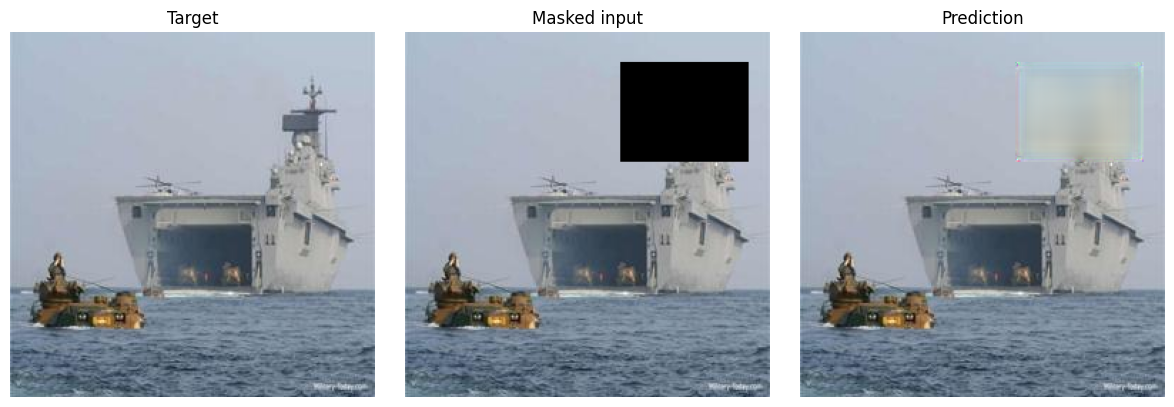

In [65]:
# Qualitative sanity check: Visually inspect the model output on a held-out test sample 
x_in, img, mask = test_data[TEST_SAMPLE_IDX]
pred_unet = predict_one(best_unet, x_in, img, mask, device=DEVICE)

fig, ax = show_img_grid(
    tensors=[img, x_in, pred_unet.squeeze(0)],
    titles=["Target", "Masked input", "Prediction"],
)
plt.show()

In [66]:
# Free up GPU memory immediately after training to avoid OOM error
cleanup(best_unet)

# Evaluation

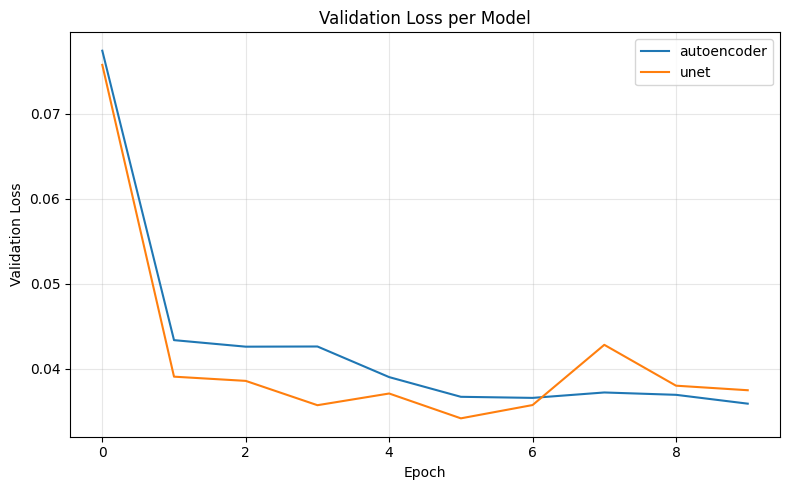

In [67]:
loss_dict = {
    "autoencoder": results_autoencoder["val_mae"],
    "unet": results_unet["val_mae"],
    }

fig, ax = plot_val_losses(loss_dict, title="Validation Loss per Model")
plt.show()

### Quantitative Comparison
To verify the impact of skip connections, we analyze the validation loss curves of both models trained under identical hyperparameters (learning rate, batch size, and seed).


# TODO

# ToDo: Missing


### To do before sharing:
- explaining setup
- understand if mask is implemented correctly



#### Must:
* Name sources for metrics, architecture etc.
* implement universal environment setup
* set up hyperparameter search
* can I use hypothesis test to see if model A or model B better
* Evaluation: Show
    - Original image (done)
    - Masked input (done)
    - Reconstruction (done)
    - Error map (!! todo)
* Finish section explanations (Evaluation baseline, Evaluation models)
* Change Loss: Optimization / Learning Problem in Inpainting (below)


### Nice to have: 
* Implement strokes as masks



### Learning Problem: 
The term $\mathrm{MAE}_{miss}$ teaches the model to fill in the missing region.
But the model still outputs values for the whole image, so it can accidentally shift colors, blur edges, or alter textures in the known area (especially near the boundary) without being punished.
Therefore it is better to add a secondary objective:
$$
L \;=\; \mathrm{MAE}_{\text{miss}} \;+\; \lambda \cdot \mathrm{MAE}_{\text{known}} .
$$

The core idea is to train mainly on the hole, but also add a small penalty if the model changes pixels that were already visible. The hyperparameter $\lambda$ acts as a "soft constraint", defining how much focus the model should give to this secondary objective.

Change Code inside loss function (in normalized space for training loss):
```
missing = 1 - mask
known = mask

abs_err = (y_hat - y).abs()
mae_miss = (abs_err * missing).sum() / (missing.sum() * C + eps)
mae_known = (abs_err * known).sum() / (known.sum() * C + eps)

loss = mae_miss + 0.1 * mae_known
```

### Note on Perceptual Loss
Even though perceptual loss can reduce blurriness, we use a pixel-wise loss to keep the experiment controlled. This lets us isolate and compare the architectural effect of skip connections (U-Net) versus a bottleneck-only autoencoder. 

In addition, it avoids the memory and compute overhead of running a frozen VGG-19 network during training, enabling more efficient experimentation under our resource constraints.

Integrating Perceptual Loss and Adversarial Loss (GANs) would be the next logical step for future work. 

